# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# df = pd.read_csv("../student_performance_raw.csv")
df = pd.read_csv("/kaggle/input/datasets/agungkagglele/dataset-raw-student/student_performance_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,passed
0,GP,M,21,R,GT3,T,2,4,2,2,2,yes,yes,yes,yes,yes,yes,no,yes,4,5,3,3,2,2,82,6,1,20,1
1,MS,F,18,R,LE3,T,0,0,3,4,1,yes,yes,no,yes,no,no,yes,no,2,2,4,3,1,5,85,10,14,0,0
2,GP,F,20,R,LE3,T,4,0,3,3,1,yes,yes,yes,no,yes,yes,yes,yes,1,5,1,4,2,5,56,7,3,3,0
3,GP,F,22,R,LE3,T,2,4,2,2,1,yes,no,no,yes,no,no,no,no,4,1,1,4,1,4,64,13,4,0,0
4,GP,F,22,U,GT3,A,1,2,2,2,0,yes,no,no,yes,no,no,yes,yes,1,3,5,2,1,4,68,1,14,12,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
print("=== Info Dataset ===\n")
df.info()
print("\n")
print("=== Statistik Deskriptif ===")
df.describe()

=== Info Dataset ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1000 non-null   object
 1   sex         1000 non-null   object
 2   age         1000 non-null   int64 
 3   address     1000 non-null   object
 4   famsize     1000 non-null   object
 5   Pstatus     1000 non-null   object
 6   Medu        1000 non-null   int64 
 7   Fedu        1000 non-null   int64 
 8   traveltime  1000 non-null   int64 
 9   studytime   1000 non-null   int64 
 10  failures    1000 non-null   int64 
 11  schoolsup   1000 non-null   object
 12  famsup      1000 non-null   object
 13  paid        1000 non-null   object
 14  activities  1000 non-null   object
 15  nursery     1000 non-null   object
 16  higher      1000 non-null   object
 17  internet    1000 non-null   object
 18  romantic    1000 non-null   object
 19  famrel      1000 non-null  

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,passed
count,1000.000000,1000.00000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,18.453000,1.98900,2.061000,2.45800,2.49800,1.439000,2.996000,3.022000,2.99800,2.97700,2.929000,3.056000,45.892000,9.84800,10.021000,10.128000,0.533000
std,2.293698,1.41947,1.392558,1.10429,1.11231,1.112437,1.412792,1.406945,1.43738,1.41438,1.402828,1.425797,27.202469,6.09377,5.924496,6.049315,0.499159
min,15.000000,0.00000,0.000000,1.00000,1.00000,0.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,16.000000,1.00000,1.000000,2.00000,2.00000,0.000000,2.000000,2.000000,2.00000,2.00000,2.000000,2.000000,21.750000,5.00000,5.000000,5.000000,0.000000
50%,18.000000,2.00000,2.000000,2.00000,3.00000,1.000000,3.000000,3.000000,3.00000,3.00000,3.000000,3.000000,47.000000,10.00000,10.000000,10.000000,1.000000
75%,20.000000,3.00000,3.000000,3.00000,3.00000,2.000000,4.000000,4.000000,4.00000,4.00000,4.000000,4.000000,69.000000,15.00000,15.000000,15.000000,1.000000
max,22.000000,4.00000,4.000000,4.00000,4.00000,3.000000,5.000000,5.000000,5.00000,5.00000,5.000000,5.000000,93.000000,20.00000,20.000000,20.000000,1.000000


In [4]:
print("Missing values:\n")
print(df.isnull().sum())
print("\n")
print("Duplikat:", df.duplicated().sum())

Missing values:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
passed        0
dtype: int64


Duplikat: 0


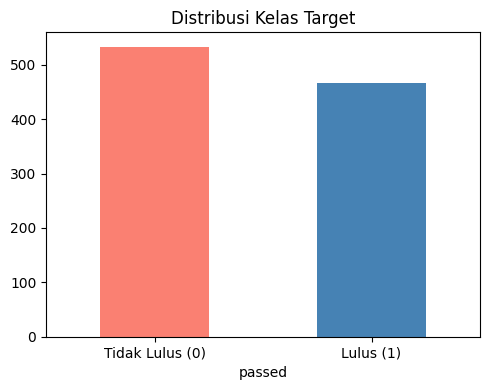

passed
1    0.533
0    0.467
Name: proportion, dtype: float64


In [5]:
# Distribusi target
fig, ax = plt.subplots(figsize=(5,4))
df["passed"].value_counts().plot(kind="bar", ax=ax, color=["salmon","steelblue"])
ax.set_title("Distribusi Kelas Target")
ax.set_xticklabels(["Tidak Lulus (0)","Lulus (1)"], rotation=0)
plt.tight_layout()
plt.show()
print(df["passed"].value_counts(normalize=True))

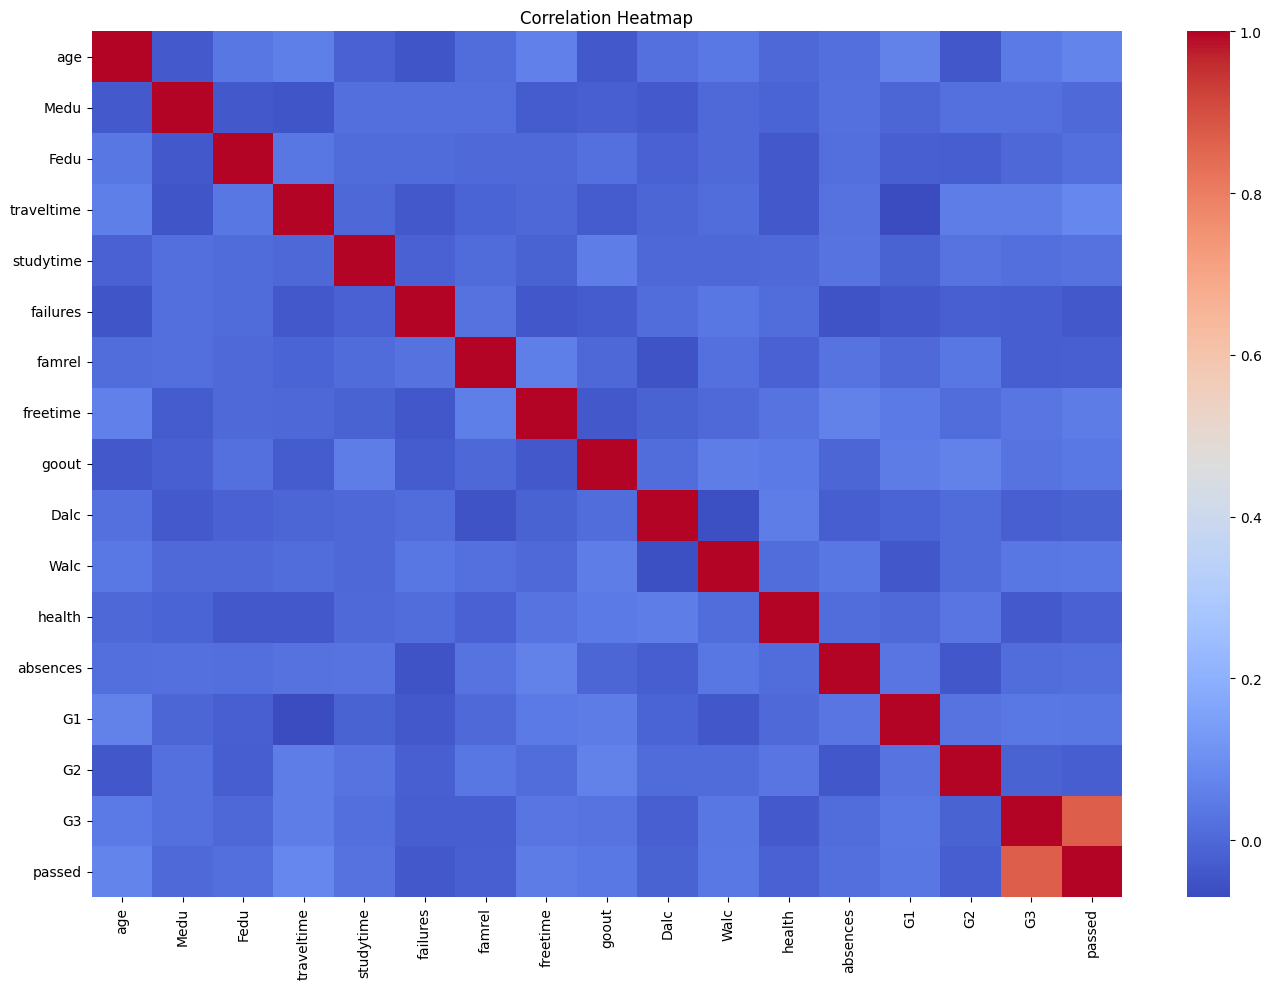

In [6]:
# Heatmap korelasi
num_cols = df.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## Data Cleaning

In [7]:
# Drop duplikat
df = df.drop_duplicates()
print("Shape setelah drop duplikat:", df.shape)

# Handle missing values
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
print("Missing values setelah cleaning:")
print(df.isnull().sum().sum())

Shape setelah drop duplikat: (1000, 30)
Missing values setelah cleaning:
0


## Feature Engineering

In [8]:
df["avg_grade"]     = (df["G1"] + df["G2"] + df["G3"]) / 3
df["total_alc"]     = df["Dalc"] + df["Walc"]
df["family_support"] = df["famsup"].map({"yes":1,"no":0}) + df["famrel"]
print("Fitur baru ditambahkan:", ["avg_grade","total_alc","family_support"])
df[["avg_grade","total_alc","family_support"]].describe()

Fitur baru ditambahkan: ['avg_grade', 'total_alc', 'family_support']


,avg_grade,total_alc,family_support
count,1000.000000,1000.00000,1000.000000
mean,9.999000,5.90600,3.491000
std,3.535117,1.92896,1.519285
min,1.333333,2.00000,1.000000
25%,7.333333,5.00000,2.000000
50%,10.000000,6.00000,3.000000
75%,12.666667,7.00000,5.000000
max,19.666667,10.00000,6.000000


## Encoding Fitur Kategorik

In [9]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  Encoded: {col}")
print("Encoding selesai. Shape:", df.shape)

  Encoded: school
  Encoded: sex
  Encoded: address
  Encoded: famsize
  Encoded: Pstatus
  Encoded: schoolsup
  Encoded: famsup
  Encoded: paid
  Encoded: activities
  Encoded: nursery
  Encoded: higher
  Encoded: internet
  Encoded: romantic
Encoding selesai. Shape: (1000, 33)


## Feature Scaling

In [10]:
TARGET = "passed"
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET]
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
print("Scaling selesai. Contoh nilai:")
df[feature_cols[:5]].describe().round(3)

Scaling selesai. Contoh nilai:


,school,sex,age,address,famsize
count,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.020,-0.949,-1.506,-0.953,-1.022
25%,-1.020,-0.949,-1.070,-0.953,-1.022
50%,0.980,-0.949,-0.198,-0.953,0.978
75%,0.980,1.053,0.675,1.049,0.978
max,0.980,1.053,1.547,1.049,0.978


## Split Dataset & Simpan

In [11]:
import os
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

os.makedirs("student_performance_preprocessing", exist_ok=True)
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)
train_df.to_csv("student_performance_preprocessing/train.csv", index=False)
test_df.to_csv("student_performance_preprocessing/test.csv",   index=False)
df.to_csv("student_performance_preprocessing/student_performance_preprocessed.csv", index=False)
print("Dataset berhasil disimpan!")

Train: (800, 32) | Test: (200, 32)
Dataset berhasil disimpan!
